# Aula Prática de Aprendizagem de Máquina

## Prevendo o Comportamento de Clientes em E-commerce (Dataset Olist)

Pós-graduação em Desenvolvimento Web — Instituto de Computação / UFAM


## Introdução: De Cliques a Avaliações

**Por que prever o comportamento do cliente:**

- A análise de dados em e-commerce foi muito além de contar vendas e monitorar tráfego; hoje ela busca entender e antecipar o que o cliente vai fazer.
- No cenário competitivo atual, essa capacidade de antecipação é um diferencial estratégico, e o feedback do cliente é um dos ativos mais valiosos de qualquer plataforma.

**O que as avaliações representam para o negócio:**

- Elas influenciam diretamente as decisões de compra de outros consumidores, funcionando como prova social.
- Ao mesmo tempo, fornecem dados preciosos para otimizar catálogos, melhorar serviços e construir a confiança na marca.

**A mudança de postura do negócio digital:**

- A pergunta deixa de ser apenas reativa — "recebemos uma avaliação?" — e passa a ser proativa e preditiva: "conseguimos prever o comportamento de avaliação de cada transação?".
- Responder a isso com precisão abre caminho para campanhas de marketing direcionadas, para otimizar a comunicação pós-venda e para criar funcionalidades que incentivem o engajamento.


### O conjunto de dados: Olist

- Vamos usar o _Brazilian E-Commerce Public Dataset by Olist_, com dados reais de um dos maiores marketplaces do Brasil.
- O conjunto contém cerca de **100.000 pedidos** feitos entre **2016 e 2018** e cobre todo o ciclo de vida da transação: a compra inicial, o processamento do pagamento e do envio e, por fim, as avaliações deixadas pelos clientes.

**Por que é um bom dataset para a aula:**

- É do mundo real, o que significa lidar com dados sujos, ausentes e estruturalmente incompletos — exatamente o tipo de desafio que aparece na prática profissional.
- É relacional, distribuído em vários arquivos conectados por chaves, o que é familiar para quem já trabalhou com banco de dados e reforça essa ponte de conhecimento.


### A jornada da prática (em paralelo com um projeto de software)

Vamos percorrer três papéis, na mesma ordem de um projeto de dados real:

1. Como **arquiteto de dados**, o foco é compreender e conectar as múltiplas fontes de dados disponíveis.
2. Como **engenheiro de dados**, passamos a limpar, transformar e preparar os dados brutos para a análise.
3. Como **engenheiro de machine learning**, construímos, treinamos e avaliamos os modelos preditivos.

**Objetivo pedagógico:**

- A ideia é desmistificar o processo de ciência de dados, mostrando que ele é uma sequência lógica de passos, e não uma caixa-preta.
- Ao longo do caminho, fica claro que habilidades de programação e raciocínio estruturado são a base para construir soluções orientadas a dados.

**O que vamos construir nesta versão da prática (três problemas):**

- Um **problema de classificação binária**, em que prevemos se um pedido receberá uma **avaliação negativa** (nota menor ou igual a 2).
- Um **problema de classificação multiclasse**, em que prevemos a **faixa de satisfação** do cliente (baixa, média ou alta).
- Um **desafio final** de classificação binária, aplicado à detecção de **fraude em cartão de crédito** sobre um dataset independente.

> **Nota didática sobre a escolha do alvo:** uma versão ingênua deste problema tentaria prever apenas _se o pedido recebeu alguma avaliação_. Acontece que quase todo pedido entregue na Olist recebe avaliação (cerca de 99%), então um modelo que simplesmente responde "sim" para tudo já acertaria ~99% — e não teria aprendido nada. Por isso escolhemos alvos com **sinal real**, ligados à _nota_ da avaliação, que de fato depende de fatores como frete, tempo de entrega e categoria do produto.


## Seção 1: Montando o Kit de Ferramentas — Configuração do Ambiente

**Por que padronizar o ambiente antes de começar:**

- Um ambiente padronizado garante que todos os participantes consigam acompanhar a prática de forma fluida e consistente, sem tropeçar em diferenças de versão.
- O uso de um ambiente virtual é uma prática recomendada em desenvolvimento de software porque isola as dependências do projeto, evitando conflitos com outras instalações do sistema.


### 1.1. Instalando os Essenciais

As bibliotecas que formam a base da ciência de dados em Python, e o papel de cada uma:

- **Pandas** é a ferramenta fundamental para manipular e analisar dados tabulares, o "Excel programável" que usaremos o tempo todo.
- **Scikit-learn** é a principal biblioteca de machine learning em Python, reunindo algoritmos e ferramentas de avaliação em uma API consistente.
- **Matplotlib e Seaborn** cuidam da visualização de dados, essenciais tanto para a exploração inicial quanto para interpretar os resultados dos modelos.
- **JupyterLab** é o ambiente de desenvolvimento interativo em que a prática acontece.

**Sobre a instalação:**

- Recomenda-se fortemente criar um ambiente virtual antes de instalar qualquer coisa, para manter o projeto isolado.
- No Google Colab, todas essas bibliotecas já vêm instaladas, então esse passo pode ser pulado.


In [1]:
# Recomenda-se criar um ambiente virtual primeiro:
#   python -m venv meu_ambiente_ds
#   source meu_ambiente_ds/bin/activate   # Mac/Linux
#   meu_ambiente_ds\Scripts\activate      # Windows
#
# pip install pandas scikit-learn matplotlib seaborn jupyterlab
#
# (No Google Colab as bibliotecas já vêm instaladas.)

### 1.2. Seu Laboratório Interativo: Jupyter & Google Colab

**Notebook não é o mesmo que uma IDE tradicional:**

- Uma IDE executa um script inteiro de uma vez, do começo ao fim; um notebook, ao contrário, organiza o código em células que podem ser executadas de forma independente.
- Essa diferença permite uma espécie de "conversa" com os dados, ideal para o desenvolvimento iterativo em que testamos, visualizamos e refinamos a análise passo a passo.

**As duas opções mais comuns:**

- O **Jupyter Notebook/Lab** é uma aplicação web que permite criar e compartilhar documentos com código ao vivo, equações, visualizações e texto narrativo em um só lugar.
- O **Google Colab** é uma alternativa na nuvem, sem instalação local, que ainda oferece acesso gratuito a recursos computacionais — excelente para quem quer começar imediatamente.

**As operações fundamentais no ambiente de notebook:**

- Criar novas células, tanto de código quanto de Markdown (usado para documentação).
- Executar células, normalmente com o atalho `Shift + Enter`.
- Usar células de Markdown para registrar o raciocínio e as conclusões ao longo do projeto, mantendo o notebook legível como um relatório.


### 1.3. Exercício 1: "Olá, Mundo da Ciência de Dados!"

**Objetivo:** este primeiro exercício serve como uma verificação de sanidade, para garantir que o ambiente de todos está configurado corretamente e que as bibliotecas foram instaladas com sucesso.

**Tarefa:** importe as bibliotecas essenciais e imprima a versão de cada uma. Se tudo rodar sem erro e as versões aparecerem, o ambiente está pronto para a prática.


In [2]:
import pandas as pd
import sklearn
import matplotlib
import seaborn as sns

# display() nem sempre existe fora do Jupyter/Colab; importamos explicitamente
from IPython.display import display

print(f"Versão do Pandas: {pd.__version__}")
print(f"Versão do Scikit-learn: {sklearn.__version__}")
print(f"Versão do Matplotlib: {matplotlib.__version__}")
print(f"Versão do Seaborn: {sns.__version__}")

Versão do Pandas: 3.0.5
Versão do Scikit-learn: 1.9.0
Versão do Matplotlib: 3.11.1
Versão do Seaborn: 0.13.2


## Seção 2: Primeiro Contato — Carregando e Explorando os Dados

**O que é a Análise Exploratória de Dados (EDA):**

- É a fase de exploração inicial em que ganhamos familiaridade com os dados antes de qualquer modelagem.
- O objetivo é entender a estrutura, o conteúdo e a qualidade dos dados, identificando desde já os problemas que precisarão ser tratados.


### 2.1. Carregando a Frota de Arquivos

**A estrutura do dataset:**

- O dataset da Olist não é um arquivo único, mas uma coleção de vários CSVs que se relacionam entre si, de forma análoga a um banco de dados relacional.
- Cada arquivo relevante é carregado em um DataFrame separado com `pd.read_csv()`, a porta de entrada para a manipulação de dados no pandas.

**Boas práticas que aplicamos no código abaixo:**

- Guardamos o caminho-base dos arquivos em uma variável (`DATA_PATH`), para não repetir o caminho toda hora e facilitar a troca de ambiente.
- Envolvemos a leitura em um bloco `try/except`, de modo que, se os arquivos não forem encontrados, o notebook exibe uma mensagem clara com o link de download em vez de quebrar com um erro obscuro.


In [3]:
# Boa prática: caminho-base em uma variável.
# Baixe o dataset em: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
DATA_PATH = './data/'  # Ajuste conforme o seu ambiente

try:
    customers_df = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
    orders_df = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
    order_items_df = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
    order_reviews_df = pd.read_csv(
        DATA_PATH + 'olist_order_reviews_dataset.csv')
    products_df = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
    translation_df = pd.read_csv(
        DATA_PATH + 'product_category_name_translation.csv')
    print("Arquivos carregados com sucesso!")
except FileNotFoundError:
    print("Erro: arquivos não encontrados. Verifique o caminho em DATA_PATH.")
    print("Download: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce")

Arquivos carregados com sucesso!


### 2.2. Reconhecimento Inicial: o Trio `head`, `info` e `describe`

Antes de qualquer análise mais complexa, é imperativo fazer uma "verificação de saúde" nos dados, e o pandas oferece três funções essenciais para esse diagnóstico:

- **`.head()`** exibe as primeiras linhas do DataFrame, dando uma amostra visual das colunas e do tipo de valor que cada uma contém.
- **`.info()`** traz um resumo técnico conciso: os nomes das colunas, o total de entradas, a contagem de valores não nulos por coluna e os tipos de dado. É a primeira ferramenta para detectar dados ausentes e tipos inadequados, como datas armazenadas como texto.
- **`.describe()`** calcula, para as colunas numéricas, estatísticas como média, mediana, desvio padrão, mínimo, máximo e quartis. Isso ajuda a entender a distribuição e a escala dos dados e a farejar possíveis outliers, como um produto com preço anormalmente alto.


In [4]:
# Análise do DataFrame de Pedidos
print("--- DataFrame de Pedidos (orders_df) ---")
display(orders_df.head())

print("\n--- Informações Técnicas (info) ---")
orders_df.info()

# Análise do DataFrame de Itens do Pedido
print("\n--- Descrição Estatística (describe) do DataFrame de Itens ---")
display(order_items_df.describe())

--- DataFrame de Pedidos (orders_df) ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



--- Informações Técnicas (info) ---
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB

--- Descrição Estatística (describe) do DataFrame de Itens ---


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


### 2.3. Entendendo o Esquema

**Aproveitando o que você já sabe de banco de dados:**

- Desenvolvedores já estão familiarizados com o conceito de esquema, e esse conhecimento se transfere diretamente para entender as relações entre as tabelas da Olist.
- O passo mais importante aqui é identificar as chaves primárias e estrangeiras que conectam os diferentes arquivos.

**As chaves centrais:**

- A chave `order_id` funciona como o elo central, conectando as tabelas de pedidos, itens e avaliações.
- A `customer_id` liga os pedidos aos clientes, enquanto a `product_id` liga os itens de pedido aos produtos.

**Mapa das tabelas:**

| DataFrame          | Chave(s)                              | Descrição                                 |
| :----------------- | :------------------------------------ | :---------------------------------------- |
| `orders_df`        | `order_id`, `customer_id`             | Uma linha por pedido, ligando ao cliente. |
| `order_reviews_df` | `order_id`, `review_id`               | Pontuações e mensagens de avaliação.      |
| `order_items_df`   | `order_id`, `product_id`, `seller_id` | Junção; um pedido pode ter vários itens.  |
| `customers_df`     | `customer_id`, `customer_unique_id`   | Localização do cliente.                   |
| `products_df`      | `product_id`                          | Categoria, tamanho e peso do produto.     |
| `translation_df`   | `product_category_name`               | Traduz categorias de PT para EN.          |

> Compreender esse esquema é pré-requisito indispensável para fazer as junções corretamente na próxima seção.


## Seção 3: Criando uma Visão Unificada — A Arte da Junção de Dados

**O objetivo desta fase:**

- Depois da exploração inicial, precisamos consolidar os DataFrames separados em um único conjunto coeso.
- Esse DataFrame unificado conterá todas as informações necessárias para a análise e para a construção dos modelos, reunindo em cada linha o pedido, o produto e a categoria.


### 3.1. Uma Estratégia de Junção Passo a Passo

Vamos construir o DataFrame final de forma incremental, usando `orders_df` como base, o que torna a lógica mais clara e facilita a depuração:

1. Na **primeira junção**, combinamos `orders_df` com `order_items_df` pela chave `order_id`.
2. Na **segunda junção**, combinamos o resultado com `products_df` pela chave `product_id`.
3. Na **terceira junção**, adicionamos os nomes das categorias em inglês a partir de `translation_df`.

**Por que fazer incremental:** enriquecer o conjunto um passo de cada vez deixa o raciocínio transparente e permite inspecionar o resultado após cada junção, pegando problemas cedo em vez de depurar tudo de uma vez no final.


### 3.2. Explicando a Lógica da Junção (`left join`)

**A decisão mais crítica desta fase é o tipo de junção**, e para quem conhece SQL os conceitos são diretamente transferíveis para o pandas.

**O que precisamos preservar:**

- O nosso alvo depende da avaliação de cada pedido, então o conjunto final precisa conter, obrigatoriamente, **todos os pedidos** do `orders_df` original — inclusive os que não foram avaliados.

**Por que um `inner join` seria um erro grave:**

- O `inner join` (que é o padrão do `pd.merge`) manteria apenas os pedidos com correspondência nos dois lados da junção.
- Ao combinar com as avaliações, isso descartaria justamente os pedidos sem avaliação, que são exatamente os casos que o modelo precisa aprender a diferenciar — e destruiria a base do problema de classificação.

**Por que o `left join` é a escolha correta:**

- Ele mantém todas as linhas do DataFrame da esquerda (no nosso caso, `orders_df`) e adiciona as colunas da direita apenas onde as chaves coincidem.
- Onde não há correspondência, as novas colunas são preenchidas com `NaN`, o que preserva o universo completo de pedidos e mantém intacta a base da nossa análise.


In [5]:
# Começando com a tabela de pedidos como base
merged_df = pd.merge(orders_df, order_items_df, on='order_id', how='left')
merged_df = pd.merge(merged_df, products_df,   on='product_id', how='left')
merged_df = pd.merge(merged_df, translation_df,

                     on='product_category_name', how='left')

print("Dimensões do DataFrame unificado:", merged_df.shape)
display(merged_df.head())

Dimensões do DataFrame unificado: (113425, 23)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,87285b34884572647811a353c7ac498a,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,595fac2a385ac33a80bd5114aec74eb8,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,aa4383b373c6aca5d8797843e5594415,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


### 3.3. ⚠️ Cuidado: Junção Duplica Linhas de Pedido

**O problema, que é fácil passar despercebido:**

- A tabela `order_items_df` tem uma linha por **item**, e não por pedido, então um pedido com três itens vira três linhas depois da junção.
- Se modelássemos assim, o mesmo pedido apareceria várias vezes, o que infla artificialmente o dataset e pode até vazar informação entre treino e teste, com o mesmo pedido caindo dos dois lados da divisão.

**A solução — agregar de volta para o grão de pedido (uma linha por `order_id`):**

- O `price` é **somado**, resultando no valor total do pedido.
- O `freight_value` também é **somado**, dando o frete total.
- A categoria (`product_category_name_english`) é resumida pegando a do **primeiro item**, uma simplificação didática razoável.
- Aproveitamos ainda para **contar os itens**, criando uma nova feature potencialmente útil.

> Trabalhar sempre no grão correto de granularidade é um princípio central da engenharia de dados, e ignorá-lo é uma das fontes mais comuns de resultados sutilmente errados.


In [6]:
# Agregação para o grão de PEDIDO (uma linha por order_id)
agg_df = merged_df.groupby('order_id').agg(
    price=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
    n_itens=('order_item_id', 'count'),
    product_category_name_english=('product_category_name_english', 'first'),
    order_status=('order_status', 'first'),
    order_purchase_timestamp=('order_purchase_timestamp', 'first'),
    order_delivered_customer_date=('order_delivered_customer_date', 'first'),
    order_estimated_delivery_date=('order_estimated_delivery_date', 'first'),
    customer_id=('customer_id', 'first'),
).reset_index()

print("Antes da agregação (nível item):", merged_df.shape)
print("Depois da agregação (nível pedido):", agg_df.shape)
display(agg_df.head())

Antes da agregação (nível item): (113425, 23)
Depois da agregação (nível pedido): (99441, 10)


,order_id,price,freight_value,n_itens,product_category_name_english,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_id
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,cool_stuff,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29 00:00:00,3ce436f183e68e07877b285a838db11a
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,pet_shop,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15 00:00:00,f6dd3ec061db4e3987629fe6b26e5cce
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,furniture_decor,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05 00:00:00,6489ae5e4333f3693df5ad4372dab6d3
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,perfumery,delivered,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20 00:00:00,d4eb9395c8c0431ee92fce09860c5a06
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,garden_tools,delivered,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17 00:00:00,58dbd0b2d70206bf40e62cd34e84d795


### 3.4. Exercício 2: Trazendo o Cliente para a Análise

**Objetivo:** enriquecer ainda mais o DataFrame incorporando a localização do cliente.

**Tarefa:** faça uma junção adicional para trazer o estado do cliente (`customer_state`), que está em `customers_df`, para dentro do `agg_df`.

**Dicas para chegar lá:**

- A chave de junção correta é `customer_id`.
- Use novamente o `left join`, para garantir que nenhum pedido seja perdido no processo.
- Depois de juntar, explore o resultado com `value_counts()` para ver quais estados aparecem com mais frequência na base.


In [7]:
# Junção do estado do cliente ao nível de pedido
agg_df = pd.merge(
    agg_df,
    customers_df[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

display(agg_df['customer_state'].value_counts().head(10))

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

## Seção 4: Forjando as Features — Pré-processamento e Engenharia

**O que faremos nesta fase:**

- Limpar os dados, tratando os valores ausentes de forma consciente e justificada.
- Criar a **variável alvo** que cada modelo vai prever, derivada da nota de avaliação.
- Transformar todas as variáveis de entrada (features) para um formato numérico que um algoritmo de machine learning consiga processar.


### 4.1. Lidando com as Lacunas: Dados Ausentes

**Como localizar os valores ausentes:**

- O comando `.isnull().sum()` conta os nulos de cada coluna de forma rápida e eficaz, dando um retrato imediato de onde estão os buracos.

**O diagnóstico dos nulos na Olist:**

- Aparecem muitos nulos em colunas como `order_approved_at`, `order_delivered_carrier_date` e `order_delivered_customer_date`.
- Esses ausentes **não são aleatórios**: pedidos com status `canceled` ou `unavailable` nunca terão datas de aprovação ou entrega, então a falta é estrutural e completamente esperada, não um defeito dos dados.

**A decisão de projeto que tomamos:**

- Não faz sentido prever a avaliação de um pedido que o cliente nunca chegou a receber, então filtramos o conjunto para manter apenas os pedidos efetivamente entregues (`order_status == 'delivered'`).
- Essa única ação resolve a maior parte do problema de dados ausentes e, de quebra, deixa o objetivo do modelo muito mais claro e bem definido.


In [8]:
# Mantém apenas pedidos entregues
df = agg_df[agg_df['order_status'] == 'delivered'].copy()

print("Contagem de valores ausentes após filtrar por 'delivered':")
print(df.isnull().sum())

# Ainda podem restar ausentes em categoria/preço/frete.
# Para simplificar a prática, removemos linhas sem as features que usaremos.
df.dropna(subset=['product_category_name_english',

          'price', 'freight_value'], inplace=True)
print("\nDimensões após limpeza:", df.shape)

Contagem de valores ausentes após filtrar por 'delivered':
order_id                            0
price                               0
freight_value                       0
n_itens                             0
product_category_name_english    1351
order_status                        0
order_purchase_timestamp            0
order_delivered_customer_date       8
order_estimated_delivery_date       0
customer_id                         0
customer_state                      0
dtype: int64

Dimensões após limpeza: (95127, 11)


### 4.2. Trazendo as Notas de Avaliação

**A diferença em relação à versão original:**

- Em vez de prever apenas _se existe_ uma avaliação — um alvo com sinal quase nulo, como discutimos na introdução — vamos prever **a nota** que o cliente deu.
- Isso transforma o exercício em um problema com sinal real, no qual as features de entrega e produto de fato ajudam a explicar o resultado.

**Os passos para preparar o alvo:**

- Reduzimos a tabela de avaliações a uma nota por pedido (`review_score`).
- Como alguns pedidos têm mais de uma avaliação, agregamos tirando a **média** das notas e arredondando para o inteiro mais próximo.
- Em seguida, fazemos um `left join` com a base de pedidos e descartamos os pedidos entregues que, por algum motivo, não têm nota registrada.


In [9]:
# Uma nota por pedido (média arredondada quando houver mais de uma avaliação)
reviews_score = (order_reviews_df
                 .groupby('order_id')['review_score']
                 .mean().round().astype('Int64')
                 .reset_index())

df = pd.merge(df, reviews_score, on='order_id', how='left')

# Mantemos apenas pedidos entregues que possuem nota
df = df.dropna(subset=['review_score']).copy()
df['review_score'] = df['review_score'].astype(int)

print("Distribuição das notas (review_score):")
print(df['review_score'].value_counts(normalize=True).sort_index())

Distribuição das notas (review_score):
review_score
1    0.096741
2    0.030808
3    0.082835
4    0.197536
5    0.592080
Name: proportion, dtype: float64


### 4.3. Engenharia de Feature: Tempo de Entrega (`delivery_time`)

**A hipótese de negócio por trás da feature:**

- É razoável supor que entregas mais demoradas tendam a gerar notas piores, então o tempo de entrega é um forte candidato a variável preditiva.

**Como calcular o tempo de entrega:**

- Primeiro convertemos as colunas de data, que vêm como texto, para o tipo `datetime` usando `pd.to_datetime()`.
- Depois subtraímos a data de compra da data de entrega, o que gera um objeto `Timedelta`, do qual extraímos o número de dias com `.dt.days`.

**Uma feature bônus, igualmente útil:**

- Calculamos também o `atraso_entrega`, a diferença em dias entre a data real de entrega e a data estimada — um valor positivo indica que o pedido atrasou em relação ao prometido, o que também pode pesar na avaliação.


In [10]:
# Conversão para datetime
for col in ['order_purchase_timestamp',
            'order_delivered_customer_date',
            'order_estimated_delivery_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Tempo de entrega (dias) e atraso em relação ao estimado (dias)
df['delivery_time'] = (df['order_delivered_customer_date']
                       - df['order_purchase_timestamp']).dt.days
df['atraso_entrega'] = (df['order_delivered_customer_date']
                        - df['order_estimated_delivery_date']).dt.days

# Remove eventuais linhas onde a conta não fechou (datas ausentes)
df = df.dropna(subset=['delivery_time', 'atraso_entrega']).copy()
df['delivery_time'] = df['delivery_time'].astype(int)
df['atraso_entrega'] = df['atraso_entrega'].astype(int)

display(df[['delivery_time', 'atraso_entrega', 'review_score']].describe())

,delivery_time,atraso_entrega,review_score
count,94481.000000,94481.000000,94481.000000
mean,12.049587,-11.921455,4.157376
std,9.461461,10.112236,1.282202
min,0.000000,-147.000000,1.000000
25%,6.000000,-17.000000,4.000000
50%,10.000000,-12.000000,5.000000
75%,15.000000,-7.000000,5.000000
max,208.000000,188.000000,5.000000


### 4.4. ⚠️ Uma Palavra sobre Vazamento de Dados (_Data Leakage_)

**O que é vazamento de dados:**

- Vazamento ocorre quando usamos como feature alguma informação que não estaria disponível no momento da previsão, ou que entrega o próprio alvo de forma indireta.
- Um modelo contaminado por leakage parece excelente na avaliação de teste, mas fracassa em produção, quando essa informação privilegiada não existe mais.

**No nosso caso está tudo certo, e é importante entender por quê:**

- Tanto o `delivery_time` quanto o `atraso_entrega` são conhecidos no momento em que o pedido é entregue.
- A avaliação, por sua vez, só acontece **depois** da entrega, então essas features realmente estariam disponíveis antes de o cliente avaliar — são legítimas para prever a nota.

**A regra prática para não errar:**

- Sempre se pergunte: "eu teria esse valor em mãos no instante exato em que preciso fazer a previsão?".
- Se a resposta for não, a feature é vazamento disfarçado e deve ser removida, por mais tentador que seja mantê-la pelo ganho de desempenho.


### 4.5. Definindo os Alvos dos Problemas A e B

**O alvo do Problema A (binário, avaliação negativa):**

- Criamos `review_negativo`, que é `True` quando a nota é menor ou igual a 2 e `False` caso contrário.
- A pergunta de negócio correspondente é direta: quais pedidos correm risco de gerar insatisfação e merecem atenção especial?

**O alvo do Problema B (multiclasse, faixa de satisfação):**

- Criamos `satisfacao`, com três faixas: `baixa` para notas 1 e 2, `media` para a nota 3 e `alta` para notas 4 e 5.
- A pergunta aqui é um pouco mais rica: em que faixa de satisfação cada pedido tende a cair, permitindo tratamentos diferenciados para cada nível?

> Repare que ambos os alvos derivam da **mesma** coluna `review_score`; o que muda entre eles é apenas o recorte aplicado e o número de classes resultante.


In [11]:
# Alvo binário (Problema A)
df['review_negativo'] = (df['review_score'] <= 2)

# Alvo multiclasse (Problema B)


def faixa_satisfacao(nota):
    if nota <= 2:
        return 'baixa'
    elif nota == 3:
        return 'media'

    return 'alta'


df['satisfacao'] = df['review_score'].apply(faixa_satisfacao)

print("Alvo A (review_negativo):")
print(df['review_negativo'].value_counts(normalize=True), "\n")
print("Alvo B (satisfacao):")
print(df['satisfacao'].value_counts(normalize=True))

Alvo A (review_negativo):
review_negativo
False    0.872451
True     0.127549
Name: proportion, dtype: float64 

Alvo B (satisfacao):
satisfacao
alta     0.789608
baixa    0.127549
media    0.082842
Name: proportion, dtype: float64


### 4.6. Seleção de Features

**As features escolhidas (as mesmas para os dois problemas):**

- Entre as numéricas, usamos `price`, `freight_value`, `n_itens`, `delivery_time` e `atraso_entrega`.
- Como variável categórica, usamos `product_category_name_english`.

**A justificativa, baseada em hipóteses testáveis de negócio:**

- Preço e frete podem moldar a expectativa do cliente e, portanto, sua satisfação com o que recebeu.
- O número de itens indica a complexidade do pedido, que pode se relacionar com problemas de entrega.
- Tempo de entrega e atraso são candidatos fortes a explicar a insatisfação, como discutimos na hipótese de negócio.
- A categoria captura diferenças de expectativa entre tipos de produto, já que o padrão de qualidade esperado varia bastante de uma categoria para outra.


In [12]:
features_num = ['price', 'freight_value',

                'n_itens', 'delivery_time', 'atraso_entrega']
features_cat = ['product_category_name_english']
features = features_num + features_cat

X = df[features].copy()
print("Matriz de features X:", X.shape)
display(X.head())

Matriz de features X: (94481, 6)


,price,freight_value,n_itens,delivery_time,atraso_entrega,product_category_name_english
0,58.90,13.29,1,7,-9,cool_stuff
1,239.90,19.93,1,16,-3,pet_shop
2,199.00,17.87,1,7,-14,furniture_decor
3,12.99,12.79,1,6,-6,perfumery
4,199.90,18.14,1,25,-16,garden_tools


### 4.7. De Categorias a Números: One-Hot Encoding (feito do jeito certo)

**Por que precisamos codificar:**

- Modelos de machine learning são, no fundo, funções matemáticas e exigem entradas numéricas — não é possível alimentar um modelo com o texto `'health_beauty'`.

**O que é o One-Hot Encoding:**

- A técnica cria uma coluna binária (0 ou 1) para cada categoria distinta, de modo que `product_category_name_english` se desdobra em várias colunas como `cat_health_beauty`, `cat_computers_accessories` e assim por diante.

**Duas armadilhas que vamos evitar, melhorando a versão original:**

- Aplicar `pd.get_dummies` **antes** da divisão treino/teste faz o vocabulário de categorias ser aprendido no dataset inteiro, o que quebra quando surge uma categoria nova no teste ou em produção; por isso usaremos o `OneHotEncoder(handle_unknown='ignore')`, que lida graciosamente com categorias não vistas.
- O `drop_first=True` é útil para modelos lineares ajustados por OLS, mas com a regularização padrão da Regressão Logística do scikit-learn ele passa a fazer o resultado depender de qual categoria foi descartada; por isso, aqui, optamos por **não** dropar categoria alguma.

> É justamente para garantir tudo isso que o encoding entrará dentro de um **`Pipeline`** na próxima seção, sendo ajustado apenas sobre os dados de treino.


## Seção 5: Problema A — Treinando o Classificador Binário

**O problema que vamos resolver:**

- A tarefa é prever `review_negativo` — se um pedido receberá nota menor ou igual a 2 — a partir das features do pedido.

**O que esta seção cobre:**

- A divisão dos dados em treino e teste, com estratificação para lidar com o desbalanceamento.
- A montagem de um **Pipeline** que junta pré-processamento e modelo, evitando os erros de codificação e escala discutidos na Seção 4.7.
- O treinamento propriamente dito da Regressão Logística.


### 5.1. A Regra de Ouro: Divisão em Treino e Teste

**Por que nunca testar com os dados de treino:**

- Avaliar o modelo com os mesmos dados usados para treiná-lo é como aplicar a um aluno uma prova com exatamente as questões que ele estudou — o resultado mede memorização, não aprendizado real.
- Esse fenômeno é o **overfitting** (sobreajuste): o modelo decora as particularidades do treino e perde a capacidade de generalizar para dados novos.

**Como a divisão evita esse problema:**

- Separamos os dados aleatoriamente em um conjunto de treino (tipicamente 70–80%) e um de teste (os 20–30% restantes).
- O modelo aprende apenas com o treino, enquanto o teste é mantido "secreto" até o final, servindo como uma simulação de dados do mundo real para uma avaliação imparcial.
- A ferramenta padrão para essa separação é a função `train_test_split` do scikit-learn.

**O papel do `stratify=y`:**

- Em problemas com classes desbalanceadas, como o nosso, esse parâmetro garante que a proporção de positivos e negativos seja a mesma no treino e no teste.
- Sem ele, corremos o risco de um dos conjuntos ficar com uma representação enviesada das classes, distorcendo tanto o treino quanto a avaliação.


In [13]:
from sklearn.model_selection import train_test_split

y_bin = df['review_negativo']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Proporção de negativos (treino):", round(y_train.mean(), 3))
print("Proporção de negativos (teste): ", round(y_test.mean(), 3))

Treino: (75584, 6) | Teste: (18897, 6)
Proporção de negativos (treino): 0.128
Proporção de negativos (teste):  0.128


### 5.2. Pré-processamento com `ColumnTransformer` + `Pipeline`

**Por que usar um Pipeline (a melhoria em relação ao original):**

- O Pipeline encapsula o pré-processamento e o modelo em um único objeto, que aprende tudo apenas com o treino e reaplica automaticamente no teste — o que elimina, por construção, o risco de vazamento.
- Ele também torna trivial trocar o modelo ou reaproveitar exatamente o mesmo fluxo em produção, sem reescrever as etapas de transformação.

**As duas transformações que aplicamos:**

- Nas features **numéricas**, usamos o `StandardScaler`, que padroniza a escala. Isso é necessário porque `price` e `freight_value` têm magnitude muito diferente das colunas 0/1 do one-hot, e a Regressão Logística regularizada é sensível à escala.
- Na feature **categórica**, usamos o `OneHotEncoder(handle_unknown='ignore')`, que converte as categorias em colunas binárias e lida sem quebrar com categorias que não apareceram no treino.


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat),
])

### 5.3. Uma Introdução Intuitiva à Regressão Logística

**Apesar do nome, é um algoritmo de classificação**, usado para prever um resultado binário (0 ou 1, `False` ou `True`). Seu funcionamento pode ser entendido em duas etapas:

1. **Combinação linear:** o modelo primeiro calcula uma pontuação por meio de uma soma ponderada das features, na forma $z = w_1 \cdot \text{price} + w_2 \cdot \text{freight\_value} + \dots + b$, em que os $w$ são os pesos (coeficientes) e $b$ é o bias (intercepto). Esse valor $z$ pode ser qualquer número real, positivo ou negativo.
2. **Transformação Sigmoide:** em seguida, essa pontuação $z$ passa por uma função em forma de "S", a função Sigmoide, que "esmaga" qualquer entrada para um valor entre 0 e 1. Esse valor de saída é interpretado como uma probabilidade, e, por convenção, uma probabilidade maior que 0.5 leva o modelo a classificar o caso como 1, e menor que 0.5, como 0.

![Função Sigmoide](https://developers.google.com/static/machine-learning/crash-course/logistic-regression/images/sigmoid_function_with_axes.png?hl=pt-br)


### 5.4. Lidando com o Desbalanceamento: `class_weight='balanced'`

**O contexto do problema:**

- As avaliações negativas são minoria na base, o que cria um desequilíbrio entre as classes.
- Sem nenhum ajuste, o modelo tende a "chutar" a classe majoritária (as avaliações positivas) e a ignorar a minoria, justamente a que mais interessa detectar.

**A solução que adotamos:**

- O parâmetro `class_weight='balanced'` faz o modelo penalizar mais fortemente os erros cometidos na classe rara.
- Na prática, isso melhora o _recall_ da classe de interesse — os negativos — que é exatamente o que o negócio quer identificar para agir a tempo.

**Outras abordagens que vale conhecer:**

- Fazer _oversampling_ da minoria (como o SMOTE) ou _undersampling_ da maioria, reequilibrando os dados antes do treino.
- Ajustar o limiar de decisão em vez do padrão de 0.5, técnica que exploraremos na seção de avaliação.


### 5.5. A Fase de Aprendizagem: `.fit()`

**O que o método `.fit()` faz por baixo dos panos:**

- Ele aplica o pré-processamento e roda o algoritmo de aprendizado sobre os dados de treino.
- Nesse processo, encontra os pesos ($w$) e o bias ($b$) que melhor mapeiam as features para o alvo, minimizando uma função de custo — no caso, a entropia cruzada, também chamada de _log loss_.

**Os parâmetros que usamos e por quê:**

- `max_iter=1000` dá ao algoritmo iterações suficientes para convergir com folga, evitando avisos de não convergência.
- `random_state=42` garante a reprodutibilidade dos resultados entre execuções.
- `class_weight='balanced'` aplica a correção de desbalanceamento que discutimos na subseção anterior.


In [15]:
model_bin = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000,
                               random_state=42,
                               class_weight='balanced')),
])

model_bin.fit(X_train, y_train)
print("Treinamento do modelo binário concluído.")

Treinamento do modelo binário concluído.


## Seção 6: Problema A — Julgando o Desempenho

**A regra de ouro da avaliação:**

- A avaliação usa exclusivamente o conjunto de teste, que o modelo nunca viu durante o treinamento, para que a estimativa de desempenho seja honesta.

**O que veremos ao longo da seção:**

- Como gerar previsões com `.predict()`.
- A acurácia e o famoso _paradoxo da acurácia_ em bases desbalanceadas.
- A matriz de confusão, que abre a acurácia em tipos de acerto e de erro.
- As métricas de precisão, recall e F1, que descrevem o comportamento por classe.
- As curvas ROC e Precision-Recall, junto com a ideia de ajustar o limiar de decisão.


### 6.1. Fazendo Previsões: `.predict()`

- O método `.predict()` aplica o pipeline treinado a cada linha de `X_test`.
- Para cada pedido, ele calcula internamente a probabilidade e aplica o limiar de 0.5, devolvendo a previsão final como `True` ou `False`.


In [16]:
y_pred = model_bin.predict(X_test)

### 6.2. A Primeira Métrica: Acurácia

**O que a acurácia mede:**

- É a métrica mais intuitiva de todas: a proporção de previsões corretas sobre o total de previsões.

**Por que ela pode ser perigosamente enganosa:**

- Em bases com classes desbalanceadas, a acurácia engana com facilidade. Um modelo "ingênuo" que simplesmente prevê sempre a classe majoritária pode alcançar uma acurácia alta — 85%, 90% ou mais — sem ter aprendido absolutamente nada.
- Esse modelo seria inútil na prática, porque falharia justamente em encontrar os casos que importam, as avaliações negativas.

**A conclusão que devemos tirar:**

- Uma acurácia alta não implica, por si só, um bom modelo — é o chamado paradoxo da acurácia.
- Para entender de verdade o que o modelo faz, precisamos de ferramentas mais detalhadas, que veremos a seguir; abaixo, já comparamos a acurácia do modelo com a de um baseline ingênuo para deixar isso concreto.


In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy:.4f}")

# Baseline ingênuo: prever sempre a classe majoritária
baseline = 1 - y_test.mean()  # proporção de positivos (classe majoritária)
print(f"Baseline (prever sempre 'não-negativo'): {baseline:.4f}")

Acurácia do modelo: 0.7549
Baseline (prever sempre 'não-negativo'): 0.8725


### 6.3. Além da Acurácia: a Matriz de Confusão

**O problema que ela resolve:**

- Em vez de resumir tudo em um único número, a matriz de confusão detalha o desempenho mostrando não apenas quantas previsões erraram, mas de que tipo foi cada erro.
- Para um problema binário, ela toma a forma de uma tabela 2×2.

**Os quatro quadrantes, no contexto do nosso problema:**

|                        | **Previsto: Não Negativo**            | **Previsto: Negativo**              |
| :--------------------- | :------------------------------------ | :---------------------------------- |
| **Real: Não Negativo** | **VN** — acerto (não era negativo)    | **FP** — alarme falso (Erro Tipo I) |
| **Real: Negativo**     | **FN** — deixou passar (Erro Tipo II) | **VP** — acerto (era negativo)      |

**Como ler a tabela:**

- A diagonal principal (VN e VP) reúne os acertos do modelo.
- As células fora da diagonal (FP e FN) reúnem os erros, e são justamente elas que fornecem a visão mais rica do comportamento do classificador.
- Visualizamos tudo como um mapa de calor (_heatmap_), o que facilita bastante a interpretação de relance.


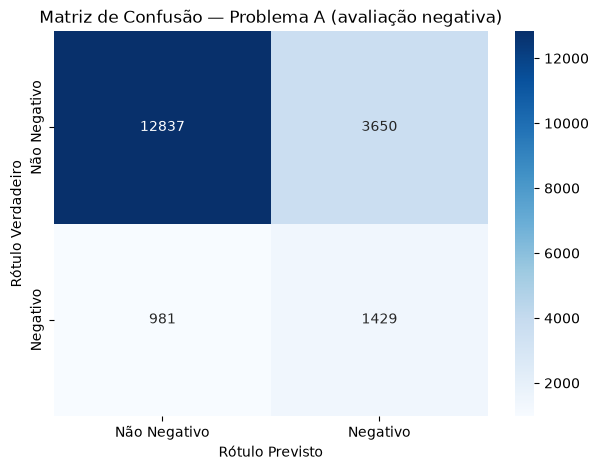

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Negativo', 'Negativo'],
            yticklabels=['Não Negativo', 'Negativo'])
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Verdadeiro')
plt.title('Matriz de Confusão — Problema A (avaliação negativa)')
plt.show()

### 6.4. Exercício 3: Precisão e Recall na Mão

A partir dos valores da matriz de confusão (VP, FP, FN e VN), calcule à mão duas das métricas mais importantes:

- A **Precisão**, definida como $\dfrac{VP}{VP + FP}$, responde: das vezes em que o modelo previu "negativo", quantas ele acertou? Ela mede a qualidade das previsões positivas.
- O **Recall** (ou sensibilidade), definido como $\dfrac{VP}{VP + FN}$, responde: de todos os negativos que de fato aconteceram, quantos o modelo conseguiu encontrar? Ele mede a capacidade de não deixar casos passarem.

**A tarefa:** calcule as duas métricas manualmente usando os valores de `cm` e discuta o significado de cada uma no contexto do negócio — o que é pior aqui, disparar um alarme falso ou deixar passar um cliente insatisfeito?


In [19]:
# ---- ESPAÇO PARA O EXERCÍCIO 3 ----
tn, fp, fn, tp = cm.ravel()
precisao = tp / (tp + fp)
recall = tp / (tp + fn)
print(f"Precisão: {precisao:.3f} | Recall: {recall:.3f}")

Precisão: 0.281 | Recall: 0.593


### 6.5. O Relatório Completo: `classification_report` e F1

**Automatizando o cálculo do exercício:**

- O `classification_report` do scikit-learn calcula precisão, recall e **F1** para cada classe de uma só vez, poupando as contas manuais.

**O que é o F1:**

- O F1 é a média harmônica entre precisão e recall, dada por $F1 = 2 \cdot \dfrac{P \cdot R}{P + R}$.
- A média harmônica só é alta quando as **duas** métricas são altas ao mesmo tempo, o que faz do F1 um ótimo resumo único para problemas desbalanceados, em que precisão e recall costumam viver em tensão.


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred,
      target_names=['Não Negativo', 'Negativo']))

              precision    recall  f1-score   support

Não Negativo       0.93      0.78      0.85     16487
    Negativo       0.28      0.59      0.38      2410

    accuracy                           0.75     18897
   macro avg       0.61      0.69      0.61     18897
weighted avg       0.85      0.75      0.79     18897



### 6.6. Curvas ROC e Precision-Recall + Ajuste de Limiar

**Por que olhar as probabilidades, e não só o 0/1:**

- O corte de 0.5 usado por padrão é arbitrário, e nem sempre é o melhor para o negócio.
- O método `.predict_proba()` devolve a probabilidade contínua de cada previsão, e ao mudar o limiar sobre essa probabilidade mudamos o equilíbrio entre precisão e recall.

**As duas curvas que analisamos:**

- A **curva ROC** e sua área (AUC) medem o quão bem o modelo separa as classes ao longo de todos os limiares possíveis — uma AUC de 0.5 equivale ao acaso e 1.0 seria perfeita.
- A **curva Precision-Recall** é mais informativa que a ROC quando os dados são muito desbalanceados, porque concentra a atenção no desempenho sobre a classe rara.

**O uso prático de tudo isso:**

- Com as curvas em mãos, escolhemos o limiar de acordo com a prioridade do negócio — mais recall para não perder clientes insatisfeitos, ou mais precisão para não incomodar quem já está satisfeito.


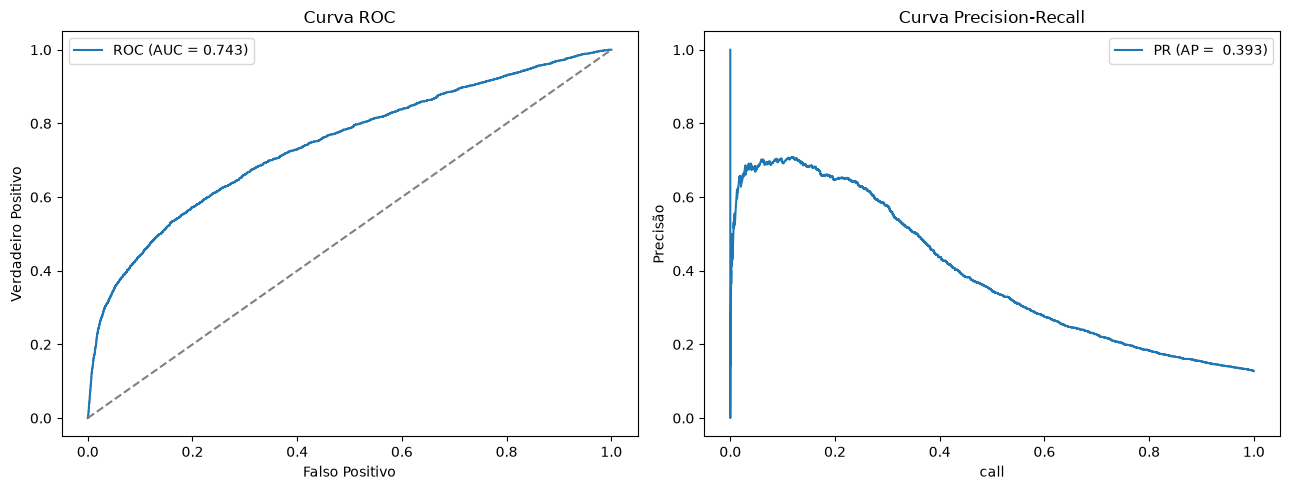

In [21]:
from sklearn.metrics import (roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)

# Probabilidade da classe positiva (negativo = True)
y_proba = model_bin.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, _ = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
ax[0].plot([0, 1], [0, 1], '--', color='gray')
ax[0].set_xlabel('Falso Positivo')

ax[0].set_ylabel('Verdadeiro Positivo')
ax[0].set_title('Curva ROC')
ax[0].legend()


ax[1].plot(rec, prec, label=f'PR (AP = {ap: .3f})')
ax[1].set_xlabel('call')
ax[1].set_ylabel('Precisão')
ax[1].set_title('Curva Precision-Recall')
ax[1].legend()
plt.tight_layout()
plt.show()

### 6.7. Interpretando o Modelo: Quais Features Pesam Mais?

**Por que interpretar o modelo:**

- Interpretar os coeficientes conecta o modelo de volta ao problema de negócio, que é justamente o enquadramento prometido na introdução da prática.
- Na Regressão Logística, o sinal e a magnitude de cada coeficiente indicam a direção e a força do efeito daquela feature sobre a probabilidade prevista.

**Como ler os coeficientes:**

- Um coeficiente **positivo** aumenta a chance de avaliação negativa, enquanto um coeficiente **negativo** reduz essa chance.
- Como padronizamos as features numéricas, os coeficientes dessas variáveis ficam comparáveis entre si, permitindo dizer quais pesam mais na decisão do modelo.


In [22]:
import numpy as np

# Recupera nomes das features após o pré-processamento
ohe = model_bin.named_steps['prep'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(features_cat)
all_names = np.concatenate([features_num, cat_names])

coefs = model_bin.named_steps['clf'].coef_[0]
coef_df = (pd.DataFrame({'feature': all_names, 'coef': coefs})
           .sort_values('coef', ascending=False))

print("Top 5 que AUMENTAM a chance de avaliação negativa:")
display(coef_df.head(5))
print("Top 5 que REDUZEM a chance de avaliação negativa:")
display(coef_df.tail(5))

Top 5 que AUMENTAM a chance de avaliação negativa:


,feature,coef
35,product_category_name_english_fashion_male_clo...,1.181329
3,delivery_time,0.630273
9,product_category_name_english_audio,0.580016
24,product_category_name_english_construction_too...,0.465492
2,n_itens,0.443046


Top 5 que REDUZEM a chance de avaliação negativa:


,feature,coef
60,product_category_name_english_music,-0.468786
13,product_category_name_english_books_general_in...,-0.500233
17,product_category_name_english_christmas_supplies,-0.517472
23,product_category_name_english_construction_too...,-0.539465
42,product_category_name_english_food_drink,-1.426208


## Seção 7: Problema B — Classificação Multiclasse (Faixa de Satisfação)

**O salto conceitual que fazemos aqui:**

- Até agora o alvo tinha apenas duas classes (`True` e `False`); a partir de agora ele passa a ter três — `baixa`, `media` e `alta`.
- A boa notícia é que quase todo o fluxo que já construímos — pipeline, divisão treino/teste e ferramentas de avaliação — se reaproveita quase sem mudanças.


### 7.1. Binário vs. Multiclasse: o que muda?

**O que permanece exatamente igual:**

- O pré-processamento continua o mesmo, com `StandardScaler` nas numéricas e `OneHotEncoder` na categórica.
- A divisão treino/teste com `stratify` e as ferramentas de avaliação, como a matriz de confusão e o `classification_report`, seguem valendo.

**O que de fato muda:**

- O **alvo** passa a ter três categorias, agora na coluna `satisfacao`.
- A **Regressão Logística** trata mais de duas classes por meio da estratégia _multinomial_ (softmax): em vez de uma única sigmoide, ela calcula uma probabilidade para cada classe e escolhe a de maior probabilidade.
- A **matriz de confusão** deixa de ser 2×2 e passa a ser 3×3.
- As métricas de **precisão, recall e F1** passam a ser calculadas por classe, com médias (`macro` e `weighted`) para resumir o desempenho geral em um número.


### 7.2. Preparando os Dados do Problema B

- Reaproveitamos exatamente a mesma matriz de features `X` do problema anterior, sem recalcular nada.
- A única troca é o alvo, que agora é a coluna `df['satisfacao']` em vez de `review_negativo`.
- Mantemos a estratificação na divisão, o que é importante porque as três faixas de satisfação também são desbalanceadas entre si.


In [23]:
y_multi = df['satisfacao']

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

print("Treino:", Xm_train.shape, "| Teste:", Xm_test.shape)
print("\nDistribuição das classes (treino):")
print(ym_train.value_counts(normalize=True))

Treino: (75584, 6) | Teste: (18897, 6)

Distribuição das classes (treino):
satisfacao
alta     0.789612
baixa    0.127553
media    0.082835
Name: proportion, dtype: float64


### 7.3. Treinando o Classificador Multiclasse

**Os detalhes do modelo:**

- Reutilizamos o **mesmo** objeto `preprocessor` construído na Seção 5, reforçando a vantagem de ter encapsulado o pré-processamento em um pipeline.
- Aplicamos novamente `class_weight='balanced'`, pela mesma razão de antes: as classes têm tamanhos bem diferentes.
- A Regressão Logística do scikit-learn detecta automaticamente que há mais de duas classes e passa a usar a formulação multinomial, sem que precisemos configurar isso manualmente.


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model_multi = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000,
                               random_state=42,
                               class_weight='balanced')),
])

model_multi.fit(Xm_train, ym_train)
ym_pred = model_multi.predict(Xm_test)
print("Treinamento do modelo multiclasse concluído.")

Treinamento do modelo multiclasse concluído.


### 7.4. Avaliando o Modelo Multiclasse

**A acurácia, com a mesma ressalva de antes:**

- Ela continua sendo um número único e ainda pode enganar quando as classes são desbalanceadas, então serve apenas como um primeiro retrato.

**O relatório por classe:**

- O `classification_report` mostra precisão, recall e F1 de cada uma das três faixas separadamente.
- Vale prestar atenção especial às médias que ele traz: a **`macro avg`** é a média simples entre as classes, tratando todas como igualmente importantes e sendo, por isso, sensível ao desempenho na classe rara; a **`weighted avg`** pondera cada classe pelo seu tamanho, refletindo melhor o desempenho na base como um todo.


In [25]:
from sklearn.metrics import accuracy_score, classification_report

acc_multi = accuracy_score(ym_test, ym_pred)
print(f"Acurácia (multiclasse): {acc_multi:.4f}\n")
print(classification_report(ym_test, ym_pred))

Acurácia (multiclasse): 0.6045

              precision    recall  f1-score   support

        alta       0.87      0.65      0.75     14921
       baixa       0.33      0.53      0.40      2410
       media       0.10      0.25      0.15      1566

    accuracy                           0.60     18897
   macro avg       0.43      0.48      0.43     18897
weighted avg       0.74      0.60      0.65     18897



### 7.5. Matriz de Confusão 3×3

**Como ler a matriz no caso multiclasse:**

- Cada **linha** representa a classe verdadeira e cada **coluna**, a classe prevista pelo modelo.
- A diagonal principal traz os acertos de cada faixa, enquanto as células fora dela revelam com qual outra classe cada grupo é confundido.
- É comum, por exemplo, que a faixa `media` seja confundida com `alta` ou `baixa`, justamente por ocupar a fronteira entre as duas — um padrão que a matriz deixa visível de imediato.


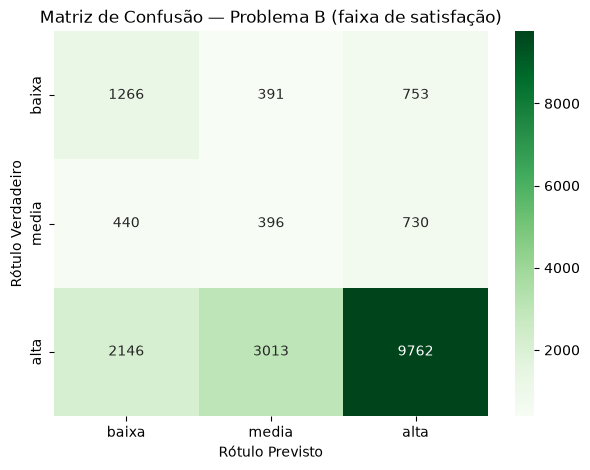

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

labels = ['baixa', 'media', 'alta']
cm_multi = confusion_matrix(ym_test, ym_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Verdadeiro')
plt.title('Matriz de Confusão — Problema B (faixa de satisfação)')
plt.show()

### 7.6. Exercício 4: Analisando as Confusões

**A tarefa, que combina discussão e código:**

- Na matriz 3×3, identifique qual par de classes o modelo mais confunde entre si.
- Calcule manualmente o **recall da classe `media`**, dividindo os acertos dessa faixa (o VP na linha `media`) pela soma total da linha `media`.
- Discuta por que a faixa intermediária costuma ser a mais difícil de acertar em problemas de satisfação.

**Uma extensão opcional, para quem quiser ir além:**

- Treine também uma `DecisionTreeClassifier` dentro do mesmo pipeline e compare o `classification_report` dos dois modelos.
- Modelos diferentes erram de formas diferentes, e comparar esses padrões de erro é parte essencial do trabalho de um cientista de dados.


In [27]:
# ---- ESPAÇO PARA O EXERCÍCIO 4 ----
from sklearn.tree import DecisionTreeClassifier
idx = labels.index('media')
recall_media = cm_multi[idx, idx] / cm_multi[idx, :].sum()
print(f"Recall da classe 'media': {recall_media:.3f}")

arvore = Pipeline([('prep', preprocessor),
                   ('clf', DecisionTreeClassifier(max_depth=6, random_state=42,
                                                  class_weight='balanced'))])
arvore.fit(Xm_train, ym_train)
print(classification_report(ym_test, arvore.predict(Xm_test)))

Recall da classe 'media': 0.253
              precision    recall  f1-score   support

        alta       0.87      0.61      0.72     14921
       baixa       0.40      0.49      0.44      2410
       media       0.10      0.36      0.16      1566

    accuracy                           0.58     18897
   macro avg       0.46      0.49      0.44     18897
weighted avg       0.75      0.58      0.64     18897



## Seção 8: Robustez — Validação Cruzada

**O problema de confiar em uma única divisão:**

- Um único recorte treino/teste pode simplesmente dar sorte (ou azar) na forma como os dados caíram de cada lado.
- Isso significa que a métrica obtida tem uma variância própria e pode não refletir fielmente o desempenho real do modelo.

**A ideia da validação cruzada (k-fold):**

- Dividimos os dados em _k_ partes, chamadas de "folds".
- Treinamos o modelo em _k−1_ dessas partes e testamos na parte restante, repetindo o processo _k_ vezes de modo que cada fold seja usado uma vez como teste.
- A métrica final é a média dos _k_ resultados, acompanhada do desvio padrão, o que dá uma estimativa muito mais estável e honesta.

**O papel do `StratifiedKFold`:**

- É a versão da validação cruzada que preserva a proporção das classes em cada fold, sendo por isso a escolha adequada para dados desbalanceados como os nossos.


In [28]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Exemplo com o modelo binário, usando F1 da classe positiva
scores = cross_val_score(model_bin, X, y_bin, cv=skf, scoring='f1')
print("F1 por fold:", [round(s, 3) for s in scores])
print(f"F1 médio: {scores.mean():.3f} (+/- {scores.std():.3f})")

F1 por fold: [np.float64(0.368), np.float64(0.384), np.float64(0.383), np.float64(0.37), np.float64(0.384)]
F1 médio: 0.378 (+/- 0.007)


## Seção 9: Colocando em Produção (para o time de Dev Web)

**Do notebook ao serviço em funcionamento:**

- Um modelo treinado só gera valor quando de fato serve previsões para a aplicação, e não quando fica preso em um notebook.
- Como todo o pré-processamento está dentro do **Pipeline**, salvamos um único objeto que já sabe escalar e codificar sozinho qualquer entrada nova, sem etapas soltas para lembrar.

**Serialização com `joblib`:**

- O comando `joblib.dump(modelo, 'arquivo.joblib')` grava o pipeline treinado em disco.
- O `joblib.load(...)` o recarrega para inferência, por exemplo dentro de uma API construída com Flask ou FastAPI.

**Como fazer a inferência:**

- Basta passar um DataFrame com exatamente as mesmas colunas de `X`, e o pipeline aplica automaticamente todas as transformações antes de gerar a previsão.
- Isso garante que o comportamento em produção seja idêntico ao do treino, sem discrepâncias sutis de pré-processamento.


In [29]:
import joblib

# Salvar o pipeline treinado
joblib.dump(model_bin, 'modelo_review_negativo.joblib')
print("Modelo salvo em modelo_review_negativo.joblib")

# Recarregar e prever para um pedido novo (exemplo)
modelo_carregado = joblib.load('modelo_review_negativo.joblib')

pedido_novo = pd.DataFrame([{
    'price': 120.0,
    'freight_value': 25.0,
    'n_itens': 1,
    'delivery_time': 30,       # entrega demorada
    'atraso_entrega': 8,       # atrasou 8 dias
    'product_category_name_english': 'bed_bath_table',
}])

prob = modelo_carregado.predict_proba(pedido_novo)[0, 1]
print(f"Probabilidade de avaliação negativa: {prob:.1%}")

Modelo salvo em modelo_review_negativo.joblib
Probabilidade de avaliação negativa: 82.4%


## Desafio Final: Detecção de Fraude em Cartão de Crédito

**O objetivo do desafio:**

- Consolidar todas as habilidades da prática aplicando o fluxo de trabalho completo a um problema novo e independente.

**Por que este caso foi escolhido:**

- A detecção de fraude é um clássico da ciência de dados e, assim como o nosso problema, envolve um conjunto de dados fortemente desbalanceado.
- Isso reforça de forma natural as lições sobre a importância de métricas adequadas, como a matriz de confusão e o F1, em vez de confiar apenas na acurácia.


### O Dataset

- Usaremos o dataset "Credit Card Fraud Detection", disponível publicamente na plataforma Kaggle.
- Ele contém transações anonimizadas, em que as features são componentes principais resultantes de uma transformação **PCA**, aplicada justamente para proteger a privacidade dos dados originais.
- A coluna mais importante é a `Class`, que indica se cada transação foi fraudulenta (valor 1) ou legítima (valor 0).
- Link: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud


### A Tarefa

- Desenvolva um notebook que aplique todo o fluxo de trabalho aprendido nesta prática a esse novo dataset.
- O objetivo concreto é construir e avaliar um modelo de Regressão Logística capaz de detectar transações fraudulentas.


### O Entregável

Um notebook limpo e bem comentado que execute os seguintes passos:

1. **Carregamento e exploração:** carregue o dataset de fraude e use `.info()`, `.describe()` e `.head()` para entender sua estrutura, verificando com atenção a distribuição da variável alvo `Class` e o quão rara é a fraude.
2. **Seleção de features:** como as features já são numéricas e anonimizadas, essa etapa é mais simples — use todas as colunas de `V1` a `V28`, além de `Amount`. Como dica, vale padronizar o `Amount`, já que as colunas `V*` vêm de PCA mas essa não.
3. **Divisão dos dados:** separe treino e teste lembrando de usar a estratificação (`stratify`), essencial diante do forte desequilíbrio de classes.
4. **Treinamento do modelo:** instancie e treine um `LogisticRegression`, considerando o uso de `class_weight='balanced'`.
5. **Avaliação do modelo:** calcule a acurácia, gere e visualize a matriz de confusão e produza o `classification_report` — que, com precisão, recall e F1, é bem mais informativo que a acurácia neste problema; opcionalmente, trace a curva Precision-Recall e calcule a PR-AUC.
6. **Análise e conclusão:** em uma célula de Markdown, explique por que a acurácia é uma métrica particularmente ruim para detecção de fraude, o que a matriz de confusão revela — quantas fraudes passaram (Falsos Negativos) e quantas transações legítimas foram barradas (Falsos Positivos) — e qual desses erros é mais custoso para o negócio, discutindo como o limiar poderia ser ajustado para equilibrá-los.


### Reflexão de Encerramento

Você percorreu o ciclo completo de um projeto de ML aplicado e, ao longo dele, vestiu três papéis:

- Como **arquiteto de dados**, conectou múltiplas fontes de dados por meio de suas chaves.
- Como **engenheiro de dados**, limpou os dados, agregou no grão certo, criou novas features e teve o cuidado de evitar o vazamento de informação.
- Como **engenheiro de ML**, treinou modelos binário e multiclasse, avaliou-os com métricas honestas e preparou o modelo final para produção.

O mesmo esqueleto que praticamos aqui — pipeline, divisão estratificada e avaliação que vai além da acurácia — serve para a maioria dos problemas de classificação que você vai encontrar na carreira.
